# Advanced (Optional): Monte Carlo Tree Search
Value iteration and policy iteration require a full model of the environment — the transition array $P(s^{\prime}\mid s,a)$ and reward $R(s,a)$ for every state and action — and sweep every state to convergence. Monte Carlo Tree Search (MCTS) instead builds a small, biased search tree rooted at the *current* state $s_{0}$, guided by random rollouts and the UCT (Upper Confidence bound for Trees) selection rule, and returns only the best action at the root — without ever computing $V^{\star}(s)$ for every state. This example runs MCTS on the same $5\times5$ grid world used earlier in the module (goal at $(5,5)$, reward $+100$; hazard at $(2,2)$, reward $-100$) and compares the action MCTS selects at the root to the exact optimal action $\pi^{\star}(s_{0})$ from value iteration.

Unlike the random-rollout example, which needed a *slippery*, stochastic grid world to expose its Monte Carlo estimation noise, MCTS already gets its own randomness from the random rollouts used inside the search. A deterministic grid world (no slip) therefore gives a clean, reproducible "MCTS converges to the optimal action" story below. We keep `offgrid_penalty=-1.0` so that random-rollout returns generated during the simulation phase stay bounded.

> __Learning Objectives.__
>
> This example runs Monte Carlo tree search on a deterministic grid world and compares its root decision to the exact optimal policy:
> * __The four MCTS steps:__ identify selection, expansion, simulation (rollout), and backpropagation inside the `mcts` search loop.
> * __UCT balances exploration and exploitation:__ describe how the UCT bonus $c\sqrt{\ln N(s)/N(s,a)}$ trades off revisiting actions with high estimated value against actions that have been tried only a few times.
> * __Compare the root action to the value iteration optimum:__ run `mcts` from a state and check the returned action against $\pi^{\star}(s)$ from value iteration.

Let's get started.
___


## Theory Recap
The full theory of Monte Carlo tree search — the four phases, the UCT selection rule, and pseudocode — is developed in the companion reading, `CHEME-145-M4-Advanced-ApproximatePlanning-Read-Pages.ipynb`. This example needs the shape of the search loop. Each iteration of `mcts` runs four phases from the root state $s_{0}$: __selection__ descends the existing tree by choosing, at each state, the action that maximizes the UCT score
$$
\mathrm{UCT}(s,a) = Q(s,a) + c\sqrt{\frac{\ln N(s)}{N(s,a)}},
$$
where $Q(s,a)$ is the current mean-return estimate for action $a$ at state $s$, $N(s)$ and $N(s,a)$ are visit counts, and $c>0$ is an exploration constant that balances exploitation (the first term) against exploration (the second term); __expansion__ adds the first newly reached state to the tree; __simulation__ estimates that state's value with a random rollout of `model.horizon` steps (the same rollout evaluation used in the random-rollout example, `simulate_return`); and __backpropagation__ updates $N(s,a)$ and $Q(s,a)$ by an incremental mean at every state-action pair on the path back to the root. After `model.iterations` repetitions, `mcts` returns $\arg\max_{a}Q(s_{0},a)$ — the single best action at the root — and discards the rest of the tree. Tree expansion is capped at `model.depth` moves from the root; simulation depth beyond that is covered only by the rollout horizon `model.horizon`.

## Setup
This example uses functions defined in the `src` directory and a small set of external packages. The `include(...)` call below runs `Include.jl`, which activates the local project environment, loads the packages, and includes our code. The first run may take a few minutes while packages are installed and precompiled.

In [1]:
include("Include.jl");

  Activating 

project at `~/Desktop/julia_work/CHEME-140-eCornell-Repository/courses/CHEME-145/module-4`


## Build the Grid World and the Exact Solution (Reference)
We reuse the $5\times5$ grid world with one goal cell $(5,5)$ (reward $+100$) and one hazard cell $(2,2)$ (reward $-100$); both are absorbing. This world is built __deterministically__ (no slip): the chosen action's move is always carried out, so any randomness in the results below comes only from MCTS's own random rollouts, not from the environment. If a move would carry the agent off the grid, the agent instead stays in its current cell and pays `offgrid_penalty=-1.0`, which also bounds the return of a random rollout that repeatedly bumps a wall. We solve the resulting MDP exactly with value iteration to obtain $V^{\star}$ and the optimal policy $\pi^{\star}$; this is the ground-truth reference for the MCTS root actions found below.

In [2]:
rewards = Dict{Tuple{Int,Int},Float64}((5,5)=>100.0, (2,2)=>-100.0);
world = build(MyRectangularGridWorldModel, (nrows=5, ncols=5, rewards=rewards));
absorbing = Set(keys(rewards));
mdp = build_mdp(world, 0.95; step_reward=-1.0, offgrid_penalty=-1.0, absorbing=absorbing);
sol = solve(build(MyValueIterationModel, (maxiterations=10_000, ϵ=1e-9)), mdp);
π_star = policy(Q(mdp, sol.V));

## Run MCTS from a State
`build(MyMCTSModel, ...)` sets the search budget `iterations`, the UCT exploration constant `c`, the rollout horizon `horizon`, and the maximum tree depth `depth`. `mcts(mdp, model, s0; rng)` then runs the four-phase loop from state `s0` and returns the estimated best root action. Below we run MCTS from state $(4,5)$ — one cell left of the goal — and compare the returned action to $\pi^{\star}(s)$ from value iteration.

In [3]:
let
    s0 = world.states[(4,5)];
    model = build(MyMCTSModel, (iterations = 5_000, c = 50.0, horizon = 100, depth = 20));
    a = mcts(mdp, model, s0; rng = Random.MersenneTwister(2));
    println("MCTS action = ", a, "   optimal action π*(s) = ", π_star[s0]);
end

MCTS action = 2

   optimal action π*(s) = 2


## Convergence vs. Iteration Budget
State $(4,5)$ sits right next to the goal, so even a handful of random rollouts already stumbles onto the correct greedy action — the fraction correct is already at (or near) $20/20$ at very low iteration budgets, which would make a convergence trend uninformative. To see MCTS actually *converge* as the search budget grows, we instead start from a harder state, $(1,2)$, several moves from the goal, where a small iteration budget is not yet enough tree/rollout signal to reliably identify the best root action. For each iteration budget, we rerun `mcts` with 20 different random seeds and count how often the returned root action matches $\pi^{\star}(s_{0})$.

iterations = 100:  correct root action in 7/20 runs
iterations = 300:  correct root action in 19

/20 runs
iterations = 1000:  correct root action in 20

/20 runs
iterations = 3000:  correct root action in 20

/20 runs
iterations = 10000:  correct root action in 20

/20 runs


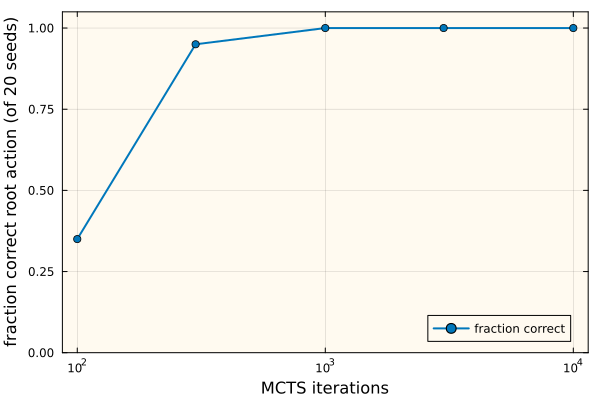

In [4]:
let
    s0 = world.states[(1,2)];
    iters_list = (100, 300, 1_000, 3_000, 10_000);
    fractions = Float64[];
    for iters ∈ iters_list
        hits = count(1:20) do trial
            model = build(MyMCTSModel, (iterations = iters, c = 50.0, horizon = 100, depth = 20));
            mcts(mdp, model, s0; rng = Random.MersenneTwister(trial)) == π_star[s0];
        end
        println("iterations = $(iters):  correct root action in ", hits, "/20 runs");
        push!(fractions, hits/20);
    end
    plot(collect(iters_list), fractions, lw = 2, marker = :circle, c = colors[1], label = "fraction correct",
        xscale = :log10, ylim = (0, 1.05), bg = "floralwhite", background_color_outside = "white", framestyle = :box,
        xlabel = "MCTS iterations", ylabel = "fraction correct root action (of 20 seeds)");
end

## Summary
This example ran Monte Carlo tree search on a deterministic $5\times5$ grid world, using `mcts` to search from a root state through repeated selection, expansion, rollout simulation, and backpropagation, and compared the resulting root action to the exact optimal action $\pi^{\star}(s_{0})$ from value iteration.

> __Key Takeaways:__
>
> * **MCTS builds a partial search tree using random rollouts:** instead of sweeping every state, `mcts` expands a small tree rooted at $s_{0}$ and evaluates unexpanded states with random-rollout returns, updating $Q(s,a)$ by backpropagation.
> * **UCT trades exploration against exploitation:** the selection rule $Q(s,a) + c\sqrt{\ln N(s)/N(s,a)}$ combines the current value estimate with a bonus for under-visited actions, controlled by the exploration constant $c$.
> * **More iterations converge to the optimal action:** at state $(1,2)$, the fraction of seeds returning the correct root action rises from a small fraction at low iteration budgets to $20/20$ at high iteration budgets, matching $\pi^{\star}(s_{0})$ from value iteration.

MCTS trades the exactness and full-state coverage of value iteration for a search that only needs a simulator and a budget of iterations to choose a single good action from the current state, converging to the optimal root action as the iteration budget grows.
___


### Additional Resources
* Kocsis, L., & Szepesvári, C. (2006). Bandit Based Monte-Carlo Planning. In _European Conference on Machine Learning (ECML)_, pp. 282–293.
* Browne, C. B., Powley, E., Whitehouse, D., Lucas, S. M., Cowling, P. I., Rohlfshagen, P., Tavener, S., Perez, D., Samothrakis, S., & Colton, S. (2012). A Survey of Monte Carlo Tree Search Methods. _IEEE Transactions on Computational Intelligence and AI in Games_, 4(1), 1–43.
* Sutton, R. S., & Barto, A. G. (2018). _Reinforcement Learning: An Introduction_ (2nd ed.), Chapter 8. MIT Press.